In [1]:
import pandas as pd
import geopandas as gpd
import missingno
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.integrate import simps
import sys
from sklearn.metrics.pairwise import euclidean_distances

sys.path.insert(0, "../../Modules")

from utils import *

enc = 'utf-8' 
dec = 'greek8'

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
raw_data = pd.read_csv('../data/GR_WNV_cases_grid_2010-2021.csv', encoding = enc)
raw_data.head(5)

,αα,Id διαχείρισης δεδομένων,Έτος,Ηλικία \r\n(σε έτη),Φύλο,Ημ/νία έναρξης συμπτωμάτων,Προσβολή ΚΝΣ (ΝΑΙ/ΟΧΙ),Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Πόλη/χωριό (/συνοικία Αθήνας) πιθανής έκθεσης,Κωδικός κανάβου κελιού 1x1 χλμ πιθανής έκθεσης,Unnamed: 12,Unnamed: 13
0,1.0,3.0,2010.0,75,ΘΗΛΥ,28-07-10,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",DW307,NaN,NaN
1,2.0,17.0,2010.0,78,ΑΡΡΕΝ,22-07-10,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,EI242,NaN,NaN
2,3.0,4.0,2010.0,70,ΘΗΛΥ,24-07-10,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,CN297,NaN,NaN
3,4.0,21.0,2010.0,74,ΑΡΡΕΝ,30-7-2010,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,CU305,NaN,NaN
4,5.0,59.0,2010.0,19,ΘΗΛΥ,06-07-10,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,BL336,NaN,NaN


In [3]:
raw_data.shape

(1421, 14)

In [4]:
data = raw_data.set_axis(['idx', 'id', 'year', 'age', 'sex', 'onset of symptoms', 'cns attack', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'unnamed1', 'unnamed2'], axis=1, inplace=False)

In [5]:
data.drop(columns = ['idx', 'id', 'cns attack', 'unnamed1', 'unnamed2'], inplace = True)
data.head(5)

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code
0,2010.0,75,ΘΗΛΥ,28-07-10,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",DW307
1,2010.0,78,ΑΡΡΕΝ,22-07-10,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,EI242
2,2010.0,70,ΘΗΛΥ,24-07-10,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,CN297
3,2010.0,74,ΑΡΡΕΝ,30-7-2010,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,CU305
4,2010.0,19,ΘΗΛΥ,06-07-10,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,BL336


In [6]:
data.shape

(1421, 9)

In [7]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,year,0.0704
1,age,0.0704
2,sex,0.0704
3,onset of symptoms,0.9148
4,nuts2,0.0704
5,nuts3,0.0704
6,lau1,0.0704
7,lau2,0.0704
8,cell_code,1.6890


In [8]:
data.dropna(axis = 0, subset = ['onset of symptoms', 'lau1', 'cell_code'], how = 'any', inplace = True)
data['onset of symptoms'] = data['onset of symptoms'].apply(lambda x : x.replace("~", ""))
data = data[data['onset of symptoms'] != 'Άγνωστη']
data = data[data['nuts2'] != 'Άγνωστη']
data = data[data['nuts2'] != 'Απροσδιόριστη']
data = data[data['nuts2'] != 'Απροσδιόριστη (Ανατολικής Μακεδονίας & Θράκης Ή Κεντρικής Μακεδονίας)']

In [9]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,year,0.0
1,age,0.0
2,sex,0.0
3,onset of symptoms,0.0
4,nuts2,0.0
5,nuts3,0.0
6,lau1,0.0
7,lau2,0.0
8,cell_code,0.0


In [10]:
data.shape

(1386, 9)

In [11]:
data['onset of symptoms'] = pd.to_datetime(data['onset of symptoms'], dayfirst=True, errors='coerce')

In [12]:
data

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code
0,2010.0,75,ΘΗΛΥ,2010-07-28,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",DW307
1,2010.0,78,ΑΡΡΕΝ,2010-07-22,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,EI242
2,2010.0,70,ΘΗΛΥ,2010-07-24,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,CN297
3,2010.0,74,ΑΡΡΕΝ,2010-07-30,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,CU305
4,2010.0,19,ΘΗΛΥ,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,BL336
...,...,...,...,...,...,...,...,...,...
1415,2021.0,85,ΑΡΡΕΝ,2021-09-13,Κεντρικής Μακεδονίας,Ημαθίας,Ηρωικής πόλης Νάουσας,Αγγελοχώρι,DQ244
1416,2021.0,52,ΘΗΛΥ,2021-09-03,Κεντρικής Μακεδονίας,Ημαθίας,Αλεξάνδρειας,Πλατύ,DU272
1417,2021.0,24,ΑΡΡΕΝ,NaT,Κεντρικής Μακεδονίας,Πέλλας,Πέλλας,Καρυώτισσα,DG254
1418,2021.0,65,ΑΡΡΕΝ,2021-10-04,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θερμαϊκού,Περαία,EK305


In [13]:
data.dropna(axis = 0, subset = ['onset of symptoms'], how = 'any', inplace = True)
data.reset_index(drop=True, inplace = True)

In [14]:
data

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code
0,2010.0,75,ΘΗΛΥ,2010-07-28,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",DW307
1,2010.0,78,ΑΡΡΕΝ,2010-07-22,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,EI242
2,2010.0,70,ΘΗΛΥ,2010-07-24,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,CN297
3,2010.0,74,ΑΡΡΕΝ,2010-07-30,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,CU305
4,2010.0,19,ΘΗΛΥ,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,BL336
...,...,...,...,...,...,...,...,...,...
1375,2021.0,46,ΑΡΡΕΝ,2021-08-31,Ανατολικής Μακεδονίας & Θράκης,Καβάλας,Παγγαίου,Παραλία Οφρυνίου (Τούζλα),DH387
1376,2021.0,85,ΑΡΡΕΝ,2021-09-13,Κεντρικής Μακεδονίας,Ημαθίας,Ηρωικής πόλης Νάουσας,Αγγελοχώρι,DQ244
1377,2021.0,52,ΘΗΛΥ,2021-09-03,Κεντρικής Μακεδονίας,Ημαθίας,Αλεξάνδρειας,Πλατύ,DU272
1378,2021.0,65,ΑΡΡΕΝ,2021-10-04,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θερμαϊκού,Περαία,EK305


In [15]:
nuts2 = data['nuts2'].drop_duplicates().sort_values().tolist()
nuts3 = data['nuts3'].drop_duplicates().sort_values().tolist()
lau1 = data['lau1'].drop_duplicates().sort_values().tolist()
lau2 = data['lau2'].drop_duplicates().sort_values().tolist()

In [16]:
with open('../data/GR_WNV_nuts2.txt', 'w', encoding=enc) as f:
    for item in nuts2:
        f.write("%s\n" % item)
        
with open('../data/GR_WNV_nuts3.txt', 'w', encoding=enc) as f:
    for item in nuts3:
        f.write("%s\n" % item)
        
with open('../data/GR_WNV_lau1.txt', 'w', encoding=enc) as f:
    for item in lau1:
        f.write("%s\n" % item)
        
with open('../data/GR_WNV_lau2.txt', 'w', encoding=enc) as f:
    for item in lau2:
        f.write("%s\n" % item)

<AxesSubplot:>

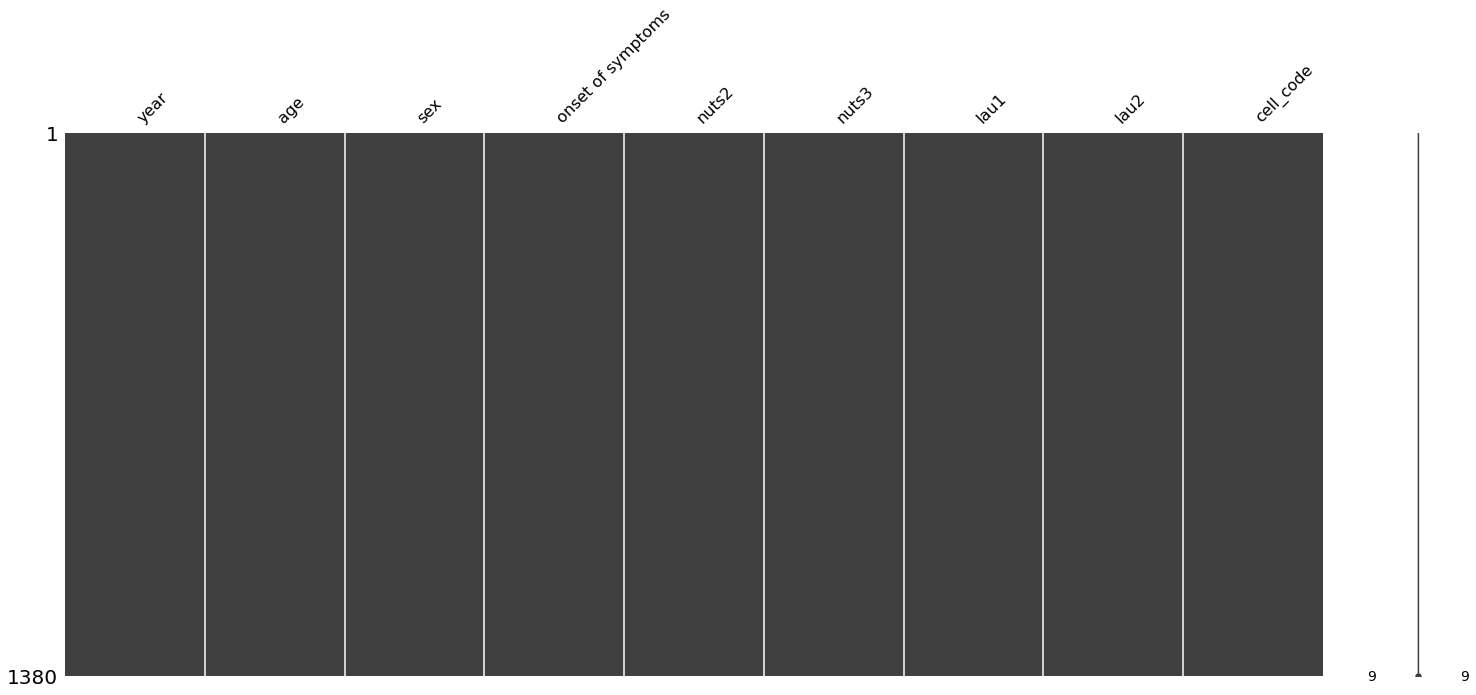

In [17]:
missingno.matrix(data)

In [18]:
process_greek(data, 'nuts2')
process_greek(data, 'nuts3')
process_greek(data, 'lau1')
process_greek(data, 'lau2')

In [19]:
data

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code
0,2010.0,75,ΘΗΛΥ,2010-07-28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307
1,2010.0,78,ΑΡΡΕΝ,2010-07-22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242
2,2010.0,70,ΘΗΛΥ,2010-07-24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297
3,2010.0,74,ΑΡΡΕΝ,2010-07-30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305
4,2010.0,19,ΘΗΛΥ,2010-07-06,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336
...,...,...,...,...,...,...,...,...,...
1375,2021.0,46,ΑΡΡΕΝ,2021-08-31,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),DH387
1376,2021.0,85,ΑΡΡΕΝ,2021-09-13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244
1377,2021.0,52,ΘΗΛΥ,2021-09-03,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,DU272
1378,2021.0,65,ΑΡΡΕΝ,2021-10-04,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια,EK305


In [20]:
data['day'] = data['onset of symptoms'].apply(lambda x : x.day)
data['month'] = data['onset of symptoms'].apply(lambda x : x.month)
data['year'] = data['onset of symptoms'].apply(lambda x : x.year)

In [21]:
nuts2_processed = data['nuts2'].drop_duplicates().sort_values().tolist()
nuts3_processed = data['nuts3'].drop_duplicates().sort_values().tolist()
lau1_processed = data['lau1'].drop_duplicates().sort_values().tolist()
lau2_processed = data['lau2'].drop_duplicates().sort_values().tolist()

In [22]:
with open('../data/GR_WNV_nuts2_processed.txt', 'w', encoding=enc) as f:
    for item in nuts2_processed:
        f.write("%s\n" % item)
        
with open('../data/GR_WNV_nuts3_processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_processed:
        f.write("%s\n" % item)
        
with open('../data/GR_WNV_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in lau1_processed:
        f.write("%s\n" % item)
        
with open('../data/GR_WNV_lau2_processed.txt', 'w', encoding=enc) as f:
    for item in lau2_processed:
        f.write("%s\n" % item)

In [23]:
data

,year,age,sex,onset of symptoms,nuts2,nuts3,lau1,lau2,cell_code,day,month
0,2010,75,ΘΗΛΥ,2010-07-28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307,28,7
1,2010,78,ΑΡΡΕΝ,2010-07-22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242,22,7
2,2010,70,ΘΗΛΥ,2010-07-24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297,24,7
3,2010,74,ΑΡΡΕΝ,2010-07-30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305,30,7
4,2010,19,ΘΗΛΥ,2010-07-06,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336,6,7
...,...,...,...,...,...,...,...,...,...,...,...
1375,2021,46,ΑΡΡΕΝ,2021-08-31,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),DH387,31,8
1376,2021,85,ΑΡΡΕΝ,2021-09-13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244,13,9
1377,2021,52,ΘΗΛΥ,2021-09-03,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,DU272,3,9
1378,2021,65,ΑΡΡΕΝ,2021-10-04,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια,EK305,4,10


In [24]:
sexes = {'ΘΗΛΥ': 'f', 'ΑΡΡΕΝ': 'm'}
data['sex'] = data['sex'].map(sexes)  

In [25]:
dataset = data.reindex(columns=['age', 'sex', 'onset of symptoms', 'year', 'month', 'day', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code'])

In [26]:
dataset

,age,sex,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,cell_code
0,75,f,2010-07-28,2010,7,28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",DW307
1,78,m,2010-07-22,2010,7,22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,EI242
2,70,f,2010-07-24,2010,7,24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,CN297
3,74,m,2010-07-30,2010,7,30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,CU305
4,19,f,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,BL336
...,...,...,...,...,...,...,...,...,...,...,...
1375,46,m,2021-08-31,2021,8,31,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),DH387
1376,85,m,2021-09-13,2021,9,13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,DQ244
1377,52,f,2021-09-03,2021,9,3,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,DU272
1378,65,m,2021-10-04,2021,10,4,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια,EK305


In [27]:
dataset.to_csv("../data/GR_WNV_cases_grid_2010-2021_processed.csv", encoding = enc, index = False)